<a href="https://colab.research.google.com/github/dercodeKoenig/test/blob/main/cryptodqn_gpu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [1]:
!git clone https://github.com/dercodeKoenig/cryptotest

Cloning into 'cryptotest'...
remote: Enumerating objects: 77, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 77 (delta 0), reused 1 (delta 0), pack-reused 74
Unpacking objects: 100% (77/77), done.
Checking out files: 100% (36/36), done.


In [2]:
!mv cryptotest/candles/ .
!ls

candles  cryptotest  drive  sample_data


In [3]:
%cd candles
import os
files = os.listdir(".")
for i in files:
  os.system("unzip "+i)
  os.system("rm "+i)
!ls
%cd ..

/content/candles
candles_object_ADAUSDT.csv   candles_object_LTCUSDT.csv
candles_object_ALGOUSDT.csv  candles_object_MANAUSDT.csv
candles_object_ATOMUSDT.csv  candles_object_MATICUSDT.csv
candles_object_BTCUSDT.csv   candles_object_SHIBUSDT.csv
candles_object_DOTUSDT.csv   candles_object_SOLUSDT.csv
candles_object_ETHUSDT.csv   candles_object_TRXUSDT.csv
/content


In [32]:
!nvidia-smi

Sun May 22 15:19:57 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   60C    P0    30W /  70W |   1002MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [4]:
import os
#os.environ["CUDA_VISIBLE_DEVICES"]="-1"
!pip install ta
import numpy as np
import tensorflow as tf
import time
import pandas as pd
import ta
from tqdm import tqdm
import random
import pickle
from collections import deque
import time
import matplotlib.pyplot as plt
from tensorflow.keras import mixed_precision

  Created wheel for ta: filename=ta-0.10.1-py3-none-any.whl size=28985 sha256=62ee9fb7c5bf1c25f577f8af5e4e9587f2d0de993961ba7f20105dc26e9cac8e
  Stored in directory: /root/.cache/pip/wheels/bc/2a/c2/a56e77d07edc16a1fa7fb012667e55cb0643cfa65996bddecc
Successfully built ta


In [5]:
def sample_to_x(sample):
        
                current_close = sample[-1].c
                current_vol = sample[-1].v

                prev_close = [candle.c for candle in sample]
                prev_high = [candle.h for candle in sample]
                prev_low = [candle.l for candle in sample]

                prev_sma21 = [candle.sma21 for candle in sample]
                prev_sma200 = [candle.sma200 for candle in sample]
                prev_vol = [candle.v for candle in sample]
                vmax = max(prev_vol)
                prev_vol_relative = [prev_vol[o] / vmax for o in range(seq_len)]
                
                
                prev_sma21_relative = [-(current_close - prev_sma21[o]) / prev_sma21[o] for o in range(seq_len)]
                prev_sma200_relative = [-(current_close - prev_sma200[o]) / prev_sma200[o] for o in range(seq_len)]
                prev_close_relative = [-(current_close - prev_close[o]) / prev_close[o] for o in range(seq_len)]
                prev_high_relative = [-(current_close - prev_high[o]) / prev_high[o] for o in range(seq_len)]
                prev_low_relative = [-(current_close - prev_low[o]) / prev_low[o] for o in range(seq_len)]

                
                
                scale = 100 # scale price: 1% -> 1

                prev_sma21_relative_scaled = [i * scale for i in prev_sma21_relative]
                prev_sma200_relative_scaled = [i * scale for i in prev_sma200_relative]

                prev_close_relative_scaled = [i * scale for i in prev_close_relative]
                prev_low_relative_scaled = [i * scale for i in prev_low_relative]
                prev_high_relative_scaled = [i * scale for i in prev_high_relative]
                prev_rsi_14 = [candle.rsi14 for candle in sample]


                x = []
                for o in range(len(prev_close)):
                    ts = []
                    ts.append(prev_close_relative_scaled[o])
                    ts.append(prev_high_relative_scaled[o])
                    ts.append(prev_low_relative_scaled[o])

                    ts.append(prev_sma21_relative_scaled[o])
                    ts.append(prev_sma200_relative_scaled[o])
                    ts.append(prev_vol_relative[o])
                    
                    ts.append(prev_rsi_14[o])

                    x.append(ts)

                x = np.array(x)
                return x
        

In [6]:
def Load(file):
    f = open(file, "rb")
    obj = pickle.load(f)
    f.close()
    return obj

In [7]:
seq_len = int(4*24*3)
comission = 0.1 / 100

class candle_class:
    pass
  
order_value = 1000

class environment():

  def __init__(self):
    pass


  def _next_observation(self):
            candles = self.candles[self.current_step - seq_len + 1:self.current_step + 1]
            
            inference_data = sample_to_x(candles)
            
            return inference_data, np.array([self.position, self.current_win])

  
  def reset(self, first_reset = False):
    self.candles = None
    candles_files = os.listdir("candles")
    use_file = "candles/"+random.choice(candles_files)
    #print(use_file)
    self.candles = Load(use_file)
    
    self.current_step = 200+seq_len if first_reset == False else random.randint(200+seq_len,len(self.candles) - 1000)
    self.position = 0
    self.entry_price = 0
    self.win = 0
    self.current_win = 0
    self.startindex = self.current_step
    self.last_reward = 0


    return self._next_observation()

  
  def close(self):
        self.win -= comission * order_value / 5*1
        self.position = 0
        self.win+=self.current_win
        self.current_win = 0
        
        
  def entry(self):
        self.entry_price = self.candles[self.current_step].c
        self.win -= comission * order_value / 5*4

  def step(self, action):
    
    if action == 0:
        if self.position != 0:
            self.close()
    
    if action == 1:
      #short
      if self.position == 1:
        self.close()

      if self.position == -1:
        pass
      else:
        self.position = -1
        self.entry()
        
    if action == 2:
      #long
      if self.position == -1:
        self.close()

      if self.position == 1:
        pass
      else:
        self.position = 1
        self.entry()
        
    self.current_step += 1
    if self.position != 0:
      current_price = self.candles[self.current_step].c
      entry = self.entry_price
      diff = (current_price - entry) / entry * order_value

      if self.position == 1:
        self.current_win = diff
      if self.position == -1:
        self.current_win = -diff

    reward_raw = self.win + self.current_win
    reward = reward_raw - self.last_reward
    self.last_reward = reward_raw
    reward = max(min(reward, 20), -20)
    done = self.current_step == len(self.candles) -1    
    
    obs = self._next_observation()
    return obs, reward, done

In [42]:
class DQNAgent:
    def __init__(self, model,
                 n_actions,
                 memory_size = 10000, 
                 optimizer = tf.keras.optimizers.Adam(0.0005), 
                 gamma = 0.99,
                 batch_size =32,
                 name = "dqn1",
                 target_model_sync = 1000,
                 exploration=0.01
                ):
        self.exploration = exploration
        self.gamma = gamma
        self.n_actions = n_actions
        self.batch_size = batch_size
        self.model = model
        self.name = name
        self.memory_size = memory_size
        self.optimizer = optimizer
        self.optimizer = mixed_precision.LossScaleOptimizer(self.optimizer)
        self.m1 = np.eye(self.n_actions, dtype="float32")
        self.target_model = tf.keras.models.clone_model(self.model)
        self.target_model_sync = target_model_sync
   
        self.memory = deque(maxlen = self.memory_size)
      
    
    
    def copy_weights(self):
        self.target_model.set_weights(self.model.get_weights())
      
    def load_weights(self):
        self.model.load_weights(self.name)
    def save_weights(self):
        self.model.save_weights(self.name, overwrite = True)
        
    @tf.function(jit_compile = True)
    def model_call(self, x):
        return tf.math.argmax(self.model(x), axis = 1)
    
    def select_actions(self, current_states, positions):
        
        if random.random() < self.exploration:
            num_inputs = len(positions)
            return tf.random.uniform(shape=[num_inputs], minval=0, maxval=3, dtype=tf.int32)
        
        return self.model_call([current_states, positions]).numpy()
        
    def observe_sasrt(self, state, action, next_state, reward, terminal):
        self.memory.append([state, action, reward, 1-int(terminal), next_state])
        
    @tf.function(jit_compile = True)
    def get_target_q(self, next_states, rewards, terminals):
        estimated_q_values_next = self.target_model(next_states)
        q_batch = tf.math.reduce_max(estimated_q_values_next, axis=1)
        target_q_values = q_batch * self.gamma * terminals + rewards
        return target_q_values
    
        
    @tf.function(jit_compile = False)
    def tstep(self, states, next_states, rewards, terminals, masks):
        target_q_values = self.get_target_q(next_states, rewards, terminals)
        
        with tf.GradientTape() as t:
            estimated_q_values = tf.math.reduce_sum(self.model(states, training=True) * masks, axis=1)
            loss = tf.keras.losses.mean_absolute_error(target_q_values, estimated_q_values)
            scaled_loss = self.optimizer.get_scaled_loss(loss)
        
        scaled_gradients = t.gradient(scaled_loss, self.model.trainable_variables)
        gradient = self.optimizer.get_unscaled_gradients(scaled_gradients)
        self.optimizer.apply_gradients(zip(gradient, self.model.trainable_variables))
        
        return loss, tf.reduce_mean(estimated_q_values)
      
    def update_parameters(self):
        sarts_batch = random.sample(self.memory, self.batch_size)
        
        states = [x[0] for x in sarts_batch]
        states_1 = np.array([x[0] for x in states], dtype="float32")
        states_2 = np.array([x[1] for x in states], dtype="float32")
        
        actions = [x[1] for x in sarts_batch]
        rewards = np.array([x[2] for x in sarts_batch], dtype="float32")
        terminals = np.array([x[3] for x in sarts_batch], dtype="float32")
        
        next_states = [x[4] for x in sarts_batch]
        next_states_1 = np.array([x[0] for x in next_states], dtype="float32")
        next_states_2 = np.array([x[1] for x in next_states], dtype="float32")
        
        masks = self.m1[actions]
        
        self.total_steps_trained+=1
        if self.total_steps_trained % self.target_model_sync == 0:
            self.copy_weights()
        
        return self.tstep([states_1, states_2], [next_states_1, next_states_2], rewards, terminals, masks)
    
    def train(self, num_steps, envs, log_interval = 1000, warmup = 0, train_steps_per_step = 1):
        self.total_steps_trained = -1

        num_envs = len(envs)
        states = [x.reset(True) for x in envs]
        
        current_episode_reward_sum = 0
        times= deque(maxlen=10)
        start_time = time.time()
        
        self.longs = 0
        self.shorts = 0

        self.total_rewards = []
        self.losses = [0]
        self.q_v = [0]
        
        def save_current_run():
            self.save_weights()
            file = open("drive/MyDrive/logs/loss_log.txt", "a")  
            for loss in self.losses:
                        file.write(str(loss))
                        file.write("\n")
            file.close()

            file = open("drive/MyDrive/logs/qv_log.txt", "a")  
            for qv in self.q_v:
                        file.write(str(qv))
                        file.write("\n")
            file.close()

            file = open("drive/MyDrive/logs/rewards_log.txt", "a")  
            for total_reward in self.total_rewards:
                        file.write(str(total_reward))
                        file.write("\n")
            file.close()
            
    

            self.total_rewards = []
            self.losses = [0]
            self.q_v = [0]
        
        try:
            for i in range(num_steps):
                if i % log_interval == 0:
                    progbar = tf.keras.utils.Progbar(log_interval, interval=0.05, stateful_metrics = ["reward sum", "t", "l/s"])
                    self.longs = 0
                    self.shorts = 0


                states_1 = np.array([x[0] for x in states])
                states_2 = np.array([x[1] for x in states])
                actions = self.select_actions(states_1, states_2)
                for action in actions:
                    if action == 1:
                        self.shorts+=1
                    elif action == 2:
                        self.longs+=1

                sasrt_pairs = []
                for index in range(num_envs):
                    sasrt_pairs.append([states[index], actions[index]]+[x for x in envs[index].step(actions[index])])

                next_states = [x[2] for x in sasrt_pairs]

                reward = [x[3] for x in sasrt_pairs]
                current_episode_reward_sum += np.sum(reward)

                self.total_rewards.extend(reward)

                for index, o in enumerate(sasrt_pairs):
                    #print(o)
                    if o[4] == True:
                        next_states[index] = envs[index].reset()
                    self.observe_sasrt(o[0], o[1], o[2], o[3], o[4])

                states = next_states
                if i > warmup:
                    for _ in range(train_steps_per_step):
                        loss, q = self.update_parameters()
                        self.losses.append(loss.numpy())
                        self.q_v.append(q.numpy())
                else:
                    loss, q = 0, 0

                end_time = time.time()
                elapsed = (end_time - start_time) * 1000
                times.append(elapsed)
                start_time = end_time


                if (i+1) % log_interval == 0:
                    save_current_run()

                progbar.update(i%log_interval+1, values = 
                               [("loss", np.mean(self.losses[-train_steps_per_step:])),
                                ("mean q", np.mean(self.q_v[-train_steps_per_step:])),
                                ("rewards", np.mean(reward)),
                                ("reward sum", current_episode_reward_sum),
                                ("l/s", (self.longs - self.shorts) / (1+self.longs+self.shorts)),
                                ("t", np.mean(times))])
        
        except KeyboardInterrupt:
            print("\n\nbreak!")
        
        save_current_run()
            


In [43]:
tf.keras.backend.clear_session()

mixed_precision.set_global_policy('mixed_float16')

if True:
  inputs_1 = tf.keras.layers.Input(shape = (seq_len, 7))
  inputs_pos = tf.keras.layers.Input(shape = (2))

  x = tf.keras.layers.Reshape((seq_len,7))(inputs_1)

  x2 = tf.keras.layers.Conv1D(128,9, padding="same")(x)
  x2 = tf.keras.layers.LeakyReLU(alpha=0.1)(x2)
  x2 = tf.keras.layers.Dense(64)(x2)
  x2 = tf.keras.layers.LeakyReLU(alpha=0.1)(x2)

  x3 = tf.keras.layers.Conv1D(128,5, padding="same")(x2)
  x3 = tf.keras.layers.LeakyReLU(alpha=0.1)(x3)
  x3 = tf.keras.layers.Dense(64)(x3)
  x3 = tf.keras.layers.LeakyReLU(alpha=0.1)(x3)

  x2 = tf.keras.layers.Add()([x2,x3])

  x = tf.keras.layers.Concatenate()([x,x2])

  x = tf.keras.layers.Dense(128)(x)
  x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)

  x2 = tf.keras.layers.Conv1D(128,5, padding="same")(x)
  x2 = tf.keras.layers.LeakyReLU(alpha=0.1)(x2)
  x = tf.keras.layers.Add()([x,x2])

  x = tf.keras.layers.Dense(128)(x)
  x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)

  x = tf.keras.layers.Conv1D(128,5, padding="same")(x)
  x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)

  x = tf.keras.layers.Dense(128)(x)
  x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)

  x = tf.keras.layers.LSTM(256)(x)

  #xe = tf.keras.layers.Lambda(lambda x: x[:,-1])(x)
  #xe = tf.keras.layers.Reshape((1,xe.shape[1]))(xe)
  #x = tf.keras.layers.MultiHeadAttention(8, x.shape[2])(xe, x)
  #x = tf.keras.layers.Add()([x, xe])
  #x = tf.keras.layers.Flatten()(x)

  x = tf.keras.layers.Concatenate()([inputs_pos, x])

  x = tf.keras.layers.Dense(512)(x)
  x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)

  x = tf.keras.layers.Dense(1024)(x)
  x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)

  x = tf.keras.layers.Dense(512)(x)
  x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)
          
  outputs = tf.keras.layers.Dense(3, activation = "linear", use_bias=False, dtype="float32")(x)
  model = tf.keras.Model([inputs_1,inputs_pos], outputs)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 288, 7)]     0           []                               
                                                                                                  
 reshape (Reshape)              (None, 288, 7)       0           ['input_1[0][0]']                
                                                                                                  
 conv1d (Conv1D)                (None, 288, 128)     8192        ['reshape[0][0]']                
                                                                                                  
 leaky_re_lu (LeakyReLU)        (None, 288, 128)     0           ['conv1d[0][0]']                 
                                                                                              

In [44]:
opt = tf.keras.optimizers.Adam(0.0001, clipvalue = 0.5)

agent = DQNAgent(
    model = model, 
    n_actions = 3, 
    memory_size = 400000,
    gamma=0.95,
    optimizer = opt, 
    batch_size = 256, 
    target_model_sync = 100,
    exploration=0.005,
    name="drive/MyDrive/deep_crypto_trading_l3.h5")

In [45]:
agent.load_weights()

In [36]:
num_parallel = 8
envs = [environment() for _ in range(num_parallel)]

In [37]:
n = int(20000)
agent.train(num_steps = n, envs = envs, warmup = n, log_interval = n, train_steps_per_step=1)

 2234/20000 [==>...........................] - ETA: 6:35 - loss: 0.0000e+00 - mean q: 0.0000e+00 - rewards: -0.0045 - reward sum: -81.0113 - l/s: -0.3656 - t: 20.7091

break!


In [38]:
len(agent.memory)

17880

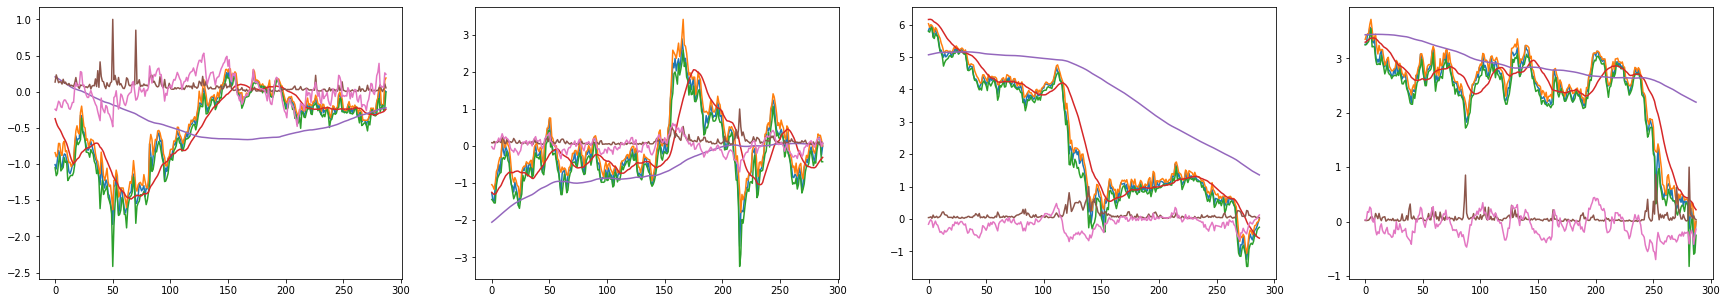

In [39]:
num_parallel = 4
envs = [environment() for _ in range(num_parallel)]

if True:    
    fig, ax = plt.subplots(1,num_parallel,figsize=(30,5))
    for o in range(num_parallel):
        x = envs[o].reset(True)[0]
        x_ = np.transpose(x)
        for i in x_:
            ax[o].plot(i) if num_parallel > 1 else ax.plot(i) 

In [ ]:
n = 100000000
agent.train(num_steps = n, envs = envs, warmup = 0, log_interval = 1000, train_steps_per_step=1)

 170/1000 [====>.........................] - ETA: 2:17 - loss: 0.0159 - mean q: -0.0235 - rewards: 8.7360e-04 - reward sum: 0.5940 - l/s: -0.8000 - t: 99.3006

In [ ]:
nx = [0,0,0]
for i in agent.memory:
    nx[i[1]]+=1
    
nx

[12006, 1146, 11312]

In [ ]:
agent.save_weights()

In [41]:
m = agent.memory

In [46]:
#agent.memory = deque(maxlen = 1000000)
for i in m:
    agent.memory.append(i)
#del m
len(agent.memory)

17892

In [ ]:
s = envs[0].reset()
p = s[1].reshape(1,2)
s = s[0].reshape(1,seq_len,7)
agent.model([s,p])

In [ ]:
for i in s.T:
  plt.plot(i)

In [ ]:
agent.batch_size = 256